<a href="https://colab.research.google.com/github/ElaineKeishamp/animal_classifier_web/blob/main/241712057_Elaine_Keisha_MP_ResponsiAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kaiellee
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:07<00:00, 93.7MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

DROPOUT_RATE = 0.3
NUM_CLASSES = 3

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['wild' 'cat' 'dog']


,image_path,labels
0,/content/animal-faces/afhq/train/wild/flickr_w...,wild
1,/content/animal-faces/afhq/train/wild/flickr_w...,wild
2,/content/animal-faces/afhq/train/wild/flickr_w...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/flickr_w...,wild


In [ ]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(data_df, test_size=0.30, random_state=42, stratify=data_df["labels"])
val, test   = train_test_split(temp, test_size=0.50, random_state=42, stratify=temp["labels"])

train = train.reset_index(drop=True)
val   = val.reset_index(drop=True)
test  = test.reset_index(drop=True)

print(train.shape, val.shape, test.shape)

(11291, 2) (2419, 2) (2420, 2)


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [ ]:
train_dataset = CustomImageDataset(dataframe=train, transform=train_transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=val_transform)
test_dataset  = CustomImageDataset(dataframe=test,  transform=val_transform)

In [ ]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/dog/pixabay_dog_001322.jpg


In [ ]:
train_dataset.__getitem__(2)

(tensor([[[-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          ...,
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323]],
 
         [[-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          ...,
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482]],
 
         [[-1.7173, -1.7173, -1.7173,  ..., -1.7173, -1.7173, -1.7173],
          [-1.7173, -1.7173,

In [ ]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

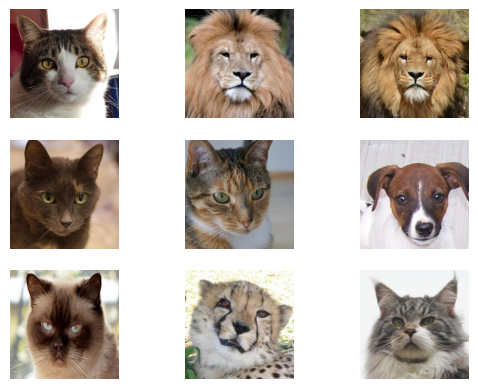

In [ ]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [ ]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 20

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
def build_mobilenet_classifier():
    backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

    for param in backbone.features.parameters():
        param.requires_grad = False

    in_features = backbone.classifier[1].in_features
    backbone.classifier = nn.Sequential(
        nn.Dropout(p=DROPOUT_RATE),
        nn.Linear(in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, NUM_CLASSES),
    )

    for m in backbone.classifier.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    return backbone

model = build_mobilenet_classifier().to(device)

for param in model.features[-3:].parameters():
    param.requires_grad = True

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters   : {total_p:,}")
print(f"Trainable parameters: {train_p:,}")

Total parameters   : 2,553,091
Trainable parameters: 1,535,299


In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
             ReLU6-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
             ReLU6-6         [-1, 32, 112, 112]               0
            Conv2d-7         [-1, 16, 112, 112]             512
       BatchNorm2d-8         [-1, 16, 112, 112]              32
  InvertedResidual-9         [-1, 16, 112, 112]               0
           Conv2d-10         [-1, 96, 112, 112]           1,536
      BatchNorm2d-11         [-1, 96, 112, 112]             192
            ReLU6-12         [-1, 96, 112, 112]               0
           Conv2d-13           [-1, 96, 56, 56]             864
      BatchNorm2d-14           [-1, 96,

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

In [ ]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []


best_val_loss = float('inf')
patience_counter = 0
EARLY_STOP_PATIENCE = 5
best_model_state = None

for epoch in range(EPOCHS):

  model.train()
  total_acc_train = 0
  total_loss_train = 0

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()
    optimizer.step()
    total_acc_train += (torch.argmax(outputs, axis=1) == labels).sum().item()


  model.eval()
  total_loss_val = 0
  total_acc_val = 0

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)
      outputs = model(inputs)
      total_loss_val += criterion(outputs, labels).item()
      total_acc_val += (torch.argmax(outputs, axis=1) == labels).sum().item()


  avg_train_loss = round(total_loss_train / len(train_loader), 4)
  avg_val_loss   = round(total_loss_val   / len(val_loader),   4)
  acc_train = round((total_acc_train / len(train_dataset)) * 100, 4)
  acc_val   = round((total_acc_val   / len(val_dataset))   * 100, 4)

  total_loss_train_plot.append(avg_train_loss)
  total_loss_validation_plot.append(avg_val_loss)
  total_acc_train_plot.append(acc_train)
  total_acc_validation_plot.append(acc_val)

  print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss} Acc: {acc_train}% | Val Loss: {avg_val_loss} Acc: {acc_val}%")


  scheduler.step(avg_val_loss)


  if avg_val_loss < best_val_loss:
    best_val_loss = avg_val_loss
    best_model_state = model.state_dict()
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter >= EARLY_STOP_PATIENCE:
      print(f"Early stopping di epoch {epoch+1}")
      break


model.load_state_dict(best_model_state)
print("Model terbaik di-load kembali!")

Epoch 1/20 | Train Loss: 1.5614 Acc: 80.7014% | Val Loss: 0.0821 Acc: 98.0984%
Epoch 2/20 | Train Loss: 0.4035 Acc: 93.9775% | Val Loss: 0.0505 Acc: 98.9665%
Epoch 3/20 | Train Loss: 0.2714 Acc: 95.9791% | Val Loss: 0.0339 Acc: 99.1319%
Epoch 4/20 | Train Loss: 0.2102 Acc: 96.6876% | Val Loss: 0.041 Acc: 99.3386%
Epoch 5/20 | Train Loss: 0.1722 Acc: 97.4847% | Val Loss: 0.0301 Acc: 99.5453%
Epoch 6/20 | Train Loss: 0.1539 Acc: 97.6973% | Val Loss: 0.0238 Acc: 99.5866%
Epoch 7/20 | Train Loss: 0.1345 Acc: 97.9807% | Val Loss: 0.0226 Acc: 99.5453%
Epoch 8/20 | Train Loss: 0.1112 Acc: 98.2995% | Val Loss: 0.0155 Acc: 99.6693%
Epoch 9/20 | Train Loss: 0.1118 Acc: 98.2198% | Val Loss: 0.0157 Acc: 99.752%
Epoch 10/20 | Train Loss: 0.0968 Acc: 98.4855% | Val Loss: 0.0215 Acc: 99.6693%
Epoch 11/20 | Train Loss: 0.0891 Acc: 98.6095% | Val Loss: 0.0173 Acc: 99.7106%
Epoch 12/20 | Train Loss: 0.0718 Acc: 98.7246% | Val Loss: 0.0166 Acc: 99.7106%
Epoch 13/20 | Train Loss: 0.0678 Acc: 98.8221% | Va

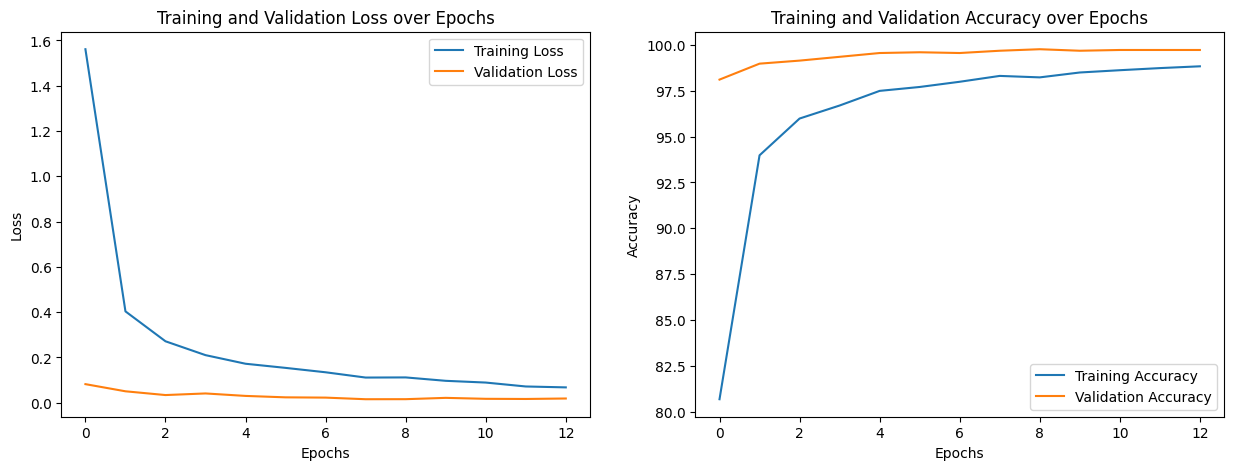

In [ ]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'label_encoder_classes': label_encoder.classes_
}, 'animal_classifier.pth')

# Download ke laptop
from google.colab import files
files.download('animal_classifier.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>